# Asistente experto en analitica de futbol profesional con Gemini, RAG y LangGraph

Proyecto final de IA Generativa: construccion de un agente experto capaz de responder preguntas sobre analitica de futbol profesional usando una base de conocimiento vectorial propia, Gemini como LLM, Gemini Embeddings, ChromaDB, LangGraph y memoria conversacional.

**Dominio elegido:** scouting y analitica avanzada de jugadores de futbol profesional en las cinco grandes ligas europeas durante la temporada 2024-2025.

## Requisitos del enunciado

Este notebook se construye para cumplir los puntos obligatorios del proyecto:

- Base de conocimiento vectorial en ChromaDB usando Gemini Embeddings.
- Minimo de 3 documentos o equivalente a unas 20 paginas de texto, usando CSV y documento propio.
- Pipeline RAG: ingesta, chunking/preprocesamiento, embeddings, almacenamiento, recuperacion y generacion.
- Agente con LangGraph que combine RAG, Gemini y memoria conversacional.
- System prompt personalizado y justificado.
- Celda de interaccion por texto dentro del notebook.
- Minimo de 5 preguntas de ejemplo con respuestas documentadas.

## 1. Instalacion de dependencias

Ejecuta esta celda solo si tu entorno no tiene instaladas las librerias. En local se recomienda usar `requirements.txt`; en Google Colab puedes descomentar la instalacion.

In [2]:
# Esta celda sirve para instalar las librerias si el entorno no las tiene.
# En local normalmente se instalan desde requirements.txt.
# En Google Colab conviene descomentar la linea siguiente y ejecutarla una vez.
!pip install -q langchain langchain-core langchain-community langchain-google-genai langchain-text-splitters langgraph chromadb python-dotenv pypdf pandas

## 2. Imports y configuracion del entorno

Las claves y configuraciones sensibles se cargan desde `.env`. No se debe hardcodear la API key en el notebook.

In [3]:
# Path permite trabajar con rutas de archivos de forma robusta en Windows, Linux o Colab.
from pathlib import Path
import os
import pandas as pd
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

# Cargamos el archivo .env para que Python pueda leer GOOGLE_API_KEY y otros parametros.
# override=True fuerza a usar el valor actual del .env aunque el kernel tuviera uno antiguo cargado.
load_dotenv(override=True)

# Leemos la clave de Gemini desde el .env.
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-2.5-flash").strip().strip('"')
GEMINI_EMBEDDING_MODEL = os.getenv("GEMINI_EMBEDDING_MODEL", "gemini-embedding-001").strip().strip('"')
CHROMA_DB_DIR = os.getenv("CHROMA_DB_DIR", "chroma_db").strip().strip('"')

# Si no hay API key, paramos el notebook con un error claro.
if not GOOGLE_API_KEY:
    raise ValueError("No se encontro GOOGLE_API_KEY. Revisa el archivo .env")

# Mostramos informacion de configuracion sin imprimir la API key completa.
print("API key cargada:", bool(GOOGLE_API_KEY))
print("Modelo Gemini:", GEMINI_MODEL)
print("Modelo embeddings:", GEMINI_EMBEDDING_MODEL)
print("Directorio Chroma:", CHROMA_DB_DIR)

c:\Users\User\miniconda3\envs\master_ds_clean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


API key cargada: True
Modelo Gemini: gemini-2.5-flash
Modelo embeddings: gemini-embedding-001
Directorio Chroma: chroma_db


## 3. Rutas del proyecto

Centralizamos las rutas para que el notebook sea mas mantenible y pueda ejecutarse desde la carpeta `notebooks` o desde la raiz del proyecto.

In [4]:
# Path.cwd() devuelve la carpeta desde la que se esta ejecutando el notebook.
NOTEBOOK_DIR = Path.cwd()

# Si ejecutamos el notebook desde la carpeta notebooks, la raiz del proyecto es el directorio padre.
# Si lo ejecutamos desde la raiz del proyecto, PROJECT_ROOT sera la carpeta actual.
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

# Carpeta donde estan los datos del proyecto.
DATA_DIR = PROJECT_ROOT / "data"

# Ruta del CSV con estadisticas de jugadores.
CSV_PATH = DATA_DIR / "players_data-2024_2025.csv"

# Lista de PDFs que formaran la base vectorial de conocimiento conceptual.
PDF_PATHS = sorted(DATA_DIR.glob("*.pdf"))

# Ruta donde ChromaDB guardara los vectores de forma persistente.
CHROMA_PATH = PROJECT_ROOT / CHROMA_DB_DIR

# Comprobamos que el CSV existe.
if not CSV_PATH.exists():
    raise FileNotFoundError(f"No se encontro el CSV requerido: {CSV_PATH}")

# Comprobamos que hay al menos 3 PDFs, como pide el enunciado.
if len(PDF_PATHS) < 3:
    raise FileNotFoundError("Se necesitan al menos 3 PDFs en la carpeta data para la base de conocimiento.")

# Imprimimos las rutas para verificar que el notebook esta leyendo los archivos correctos.
print("PROJECT_ROOT:", PROJECT_ROOT)
print("CSV:", CSV_PATH)
print("PDFs encontrados:", len(PDF_PATHS))
for pdf_path in PDF_PATHS:
    print("-", pdf_path.name)
print("ChromaDB:", CHROMA_PATH)

PROJECT_ROOT: c:\Users\User\Documents\Master Data Science_IA\IA_GENERATIVA\Asistente_Experto_LLM_Oscar_Fernandez\Asistente_Experto_LLM_Oscar_Fernandez_Evolve
CSV: c:\Users\User\Documents\Master Data Science_IA\IA_GENERATIVA\Asistente_Experto_LLM_Oscar_Fernandez\Asistente_Experto_LLM_Oscar_Fernandez_Evolve\data\players_data-2024_2025.csv
PDFs encontrados: 3
- 01_metricas_base_tiro_xg.pdf
- 02_metricas_pase_creacion_posesion.pdf
- 03_metricas_defensa_porteros_modelado_rag.pdf
ChromaDB: c:\Users\User\Documents\Master Data Science_IA\IA_GENERATIVA\Asistente_Experto_LLM_Oscar_Fernandez\Asistente_Experto_LLM_Oscar_Fernandez_Evolve\chroma_db


## 4. Inicializacion de Gemini

Creamos dos componentes: el modelo conversacional para generar respuestas y el modelo de embeddings para indexar y recuperar informacion desde ChromaDB.

In [5]:
# Creamos el modelo de lenguaje Gemini para generar respuestas.
llm = ChatGoogleGenerativeAI(
    # Modelo definido en .env, por ejemplo gemini-2.5-flash.
    model=GEMINI_MODEL,
    # API key cargada desde .env.
    google_api_key=GOOGLE_API_KEY,
    # Temperatura baja para respuestas mas consistentes y menos creativas.
    temperature=0.2,
)

# Creamos el modelo de embeddings que convertira texto en vectores numericos.
embeddings = GoogleGenerativeAIEmbeddings(
    # Modelo de embeddings definido en .env.
    model=GEMINI_EMBEDDING_MODEL,
    # API key cargada desde .env.
    google_api_key=GOOGLE_API_KEY,
)

# Confirmamos que ambos componentes se han creado.
print("LLM inicializado:", GEMINI_MODEL)
print("Embeddings inicializados:", GEMINI_EMBEDDING_MODEL)

LLM inicializado: gemini-2.5-flash
Embeddings inicializados: gemini-embedding-001


## 5. Prueba minima del LLM

Antes de construir el RAG, verificamos que Gemini responde correctamente. Esta prueba no usa todavia la base de conocimiento; solo valida conexion y configuracion.

In [6]:
# Enviamos una pregunta simple al LLM para comprobar que Gemini responde.
respuesta = llm.invoke("Explica en una frase que significa xG en futbol.")

# Imprimimos solo el contenido textual de la respuesta.
print(respuesta.content)

xG (Expected Goals) es la probabilidad de que un disparo termine en gol, calculada según la calidad de la ocasión.


## 6. Carga inicial del dataset y de los PDFs

El CSV se usara con pandas para consultar datos exactos de jugadores. Los PDFs se usaran como documentos de conocimiento para ChromaDB y el RAG.

In [7]:
# Cargamos el CSV de jugadores en un DataFrame de pandas.
df = pd.read_csv(CSV_PATH)

# Mostramos dimensiones del dataset: filas y columnas.
print("Dataset:", df.shape)

# Mostramos el numero total de columnas.
print("Columnas:", len(df.columns))

# Mostramos los PDFs disponibles para la base vectorial.
print("Documentos PDF para RAG:")
for pdf_path in PDF_PATHS:
    print("-", pdf_path.name)

# Visualizamos algunas columnas importantes para comprobar que el CSV se cargo bien.
df[["Player", "Squad", "Comp", "Pos", "Age", "Min", "xG", "xAG", "PrgC", "PrgP"]].head()

Dataset: (2854, 267)
Columnas: 267
Documentos PDF para RAG:
- 01_metricas_base_tiro_xg.pdf
- 02_metricas_pase_creacion_posesion.pdf
- 03_metricas_defensa_porteros_modelado_rag.pdf


,Player,Squad,Comp,Pos,Age,Min,xG,xAG,PrgC,PrgP
0,Max Aarons,Bournemouth,eng Premier League,DF,24.0,86,0.0,0.0,1,8
1,Max Aarons,Valencia,es La Liga,"DF,MF",24.0,120,0.0,0.0,0,6
2,Rodrigo Abajas,Valencia,es La Liga,DF,21.0,65,0.1,0.0,3,2
3,James Abankwah,Udinese,it Serie A,"DF,MF",20.0,88,0.1,0.0,3,4
4,Keyliane Abdallah,Marseille,fr Ligue 1,FW,18.0,3,0.0,0.0,1,0


## 7. Revision rapida de cobertura de datos

Comprobamos que el dataset tiene suficiente volumen y variedad para justificar el proyecto: varias ligas, posiciones y miles de registros.

In [8]:
# Mostramos cuantas filas tiene el dataset.
print("Registros:", len(df))

# Contamos cuantos jugadores/registros hay por liga.
print("Ligas:")
display(df["Comp"].value_counts())

# Contamos las posiciones mas frecuentes del dataset.
print("Posiciones principales:")
display(df["Pos"].value_counts().head(15))

Registros: 2854
Ligas:


Comp
it Serie A            634
es La Liga            601
eng Premier League    574
fr Ligue 1            553
de Bundesliga         492
Name: count, dtype: int64

Posiciones principales:


Pos
DF       859
MF       589
FW       371
FW,MF    325
MF,FW    230
GK       212
DF,MF    110
MF,DF     81
DF,FW     53
FW,DF     24
Name: count, dtype: int64

## 8. Arquitectura MVP del asistente

Para mantener el proyecto simple y defendible, usaremos una arquitectura hibrida:

- **ChromaDB + Gemini Embeddings**: para recuperar conocimiento experto desde los 3 PDFs de metricas.
- **pandas + CSV completo**: para consultas numericas exactas sobre todos los jugadores del dataset.
- **Gemini LLM**: para redactar una respuesta clara usando el contexto recuperado y, cuando aplique, los resultados calculados desde el CSV.

Esta decision evita depender de similitud semantica para filtros exactos como `xG > 15`, `Min >= 1000` o `Top 10 por xAG`, que se resuelven mejor con pandas.

## 9. System prompt personalizado

El system prompt define el rol, tono, limites y reglas del asistente. Es una parte obligatoria del enunciado y se documentara tambien en el README.

In [9]:
# Definimos el system prompt principal del asistente.
# Este texto se enviara a Gemini para indicarle como debe comportarse.
SYSTEM_PROMPT = """
Eres un asistente experto en analitica de futbol profesional, especializado en scouting, rendimiento de jugadores y metricas avanzadas.

Tu objetivo es ayudar a analizar jugadores de futbol usando dos fuentes de informacion:
1. Contexto recuperado desde ChromaDB, especialmente el glosario de metricas y fichas de scouting indexadas.
2. Resultados calculados desde el CSV con pandas cuando la pregunta requiera rankings, filtros numericos o comparaciones exactas.

Reglas de comportamiento:
- Responde en español, con tono claro, profesional y didactico.
- No inventes datos de jugadores ni valores numericos.
- Si una respuesta requiere datos exactos y no se han proporcionado resultados del CSV, indica que necesitas consultar el dataset.
- Si el contexto recuperado no contiene informacion suficiente, dilo explicitamente.
- Explica las metricas cuando sean importantes para interpretar la respuesta.
- Cuando compares jugadores, ten en cuenta posicion, minutos jugados, liga y rol.
- Prioriza respuestas breves, utiles y basadas en evidencia.

Limitaciones:
- No predigas resultados futuros como si fueran certezas.
- No des recomendaciones de apuestas.
- No afirmes que un jugador es mejor que otro sin explicar con que metricas se justifica.
""".strip()

print(SYSTEM_PROMPT)

Eres un asistente experto en analitica de futbol profesional, especializado en scouting, rendimiento de jugadores y metricas avanzadas.

Tu objetivo es ayudar a analizar jugadores de futbol usando dos fuentes de informacion:
1. Contexto recuperado desde ChromaDB, especialmente el glosario de metricas y fichas de scouting indexadas.
2. Resultados calculados desde el CSV con pandas cuando la pregunta requiera rankings, filtros numericos o comparaciones exactas.

Reglas de comportamiento:
- Responde en español, con tono claro, profesional y didactico.
- No inventes datos de jugadores ni valores numericos.
- Si una respuesta requiere datos exactos y no se han proporcionado resultados del CSV, indica que necesitas consultar el dataset.
- Si el contexto recuperado no contiene informacion suficiente, dilo explicitamente.
- Explica las metricas cuando sean importantes para interpretar la respuesta.
- Cuando compares jugadores, ten en cuenta posicion, minutos jugados, liga y rol.
- Prioriza res

### 9.1 Justificacion del system prompt

Este prompt se ha diseñado para cumplir el enunciado porque:

- Define un rol experto concreto: analista profesional de futbol.
- Obliga a usar evidencia procedente de ChromaDB y del CSV.
- Reduce alucinaciones al prohibir inventar datos numericos.
- Explica como actuar si falta informacion.
- Mantiene un tono didactico, adecuado para un usuario que quiere entender metricas y decisiones de scouting.

## 10. Preparacion de documentos PDF para RAG

Para simplificar el proyecto, la base vectorial se construye solo con los 3 PDFs de metricas. Cada pagina del PDF se convierte en un documento de LangChain con metadatos de fuente y pagina.

In [10]:
# Document es la estructura de LangChain para representar texto + metadatos.
from langchain_core.documents import Document

# RecursiveCharacterTextSplitter divide textos largos en fragmentos mas pequenos.
try:
    from langchain_text_splitters import RecursiveCharacterTextSplitter
except ModuleNotFoundError:
    from langchain.text_splitter import RecursiveCharacterTextSplitter

# Chroma es la base de datos vectorial que almacenara embeddings y documentos.
from langchain_community.vectorstores import Chroma

# PdfReader permite extraer texto de los PDFs.
from pypdf import PdfReader

### 10.1 Carga de paginas PDF como documentos

Extraemos el texto de cada pagina. Guardamos metadatos como nombre de archivo y numero de pagina para poder citar la fuente recuperada.

In [11]:
# Funcion auxiliar para corregir problemas tipicos de codificacion al extraer texto de algunos PDFs.
def repair_pdf_text(text):
    # Si aparecen caracteres como m??tricas o f??tbol, suele ser texto UTF-8 interpretado como Latin-1.
    if "?" in text or "?" in text:
        try:
            return text.encode("latin1").decode("utf-8")
        except UnicodeError:
            return text
    return text


# Lista donde guardaremos un Document por cada pagina de PDF.
pdf_page_documents = []

# Recorremos todos los PDFs encontrados en la carpeta data.
for pdf_path in PDF_PATHS:
    # Abrimos el PDF.
    reader = PdfReader(str(pdf_path))

    # Recorremos sus paginas.
    for page_number, page in enumerate(reader.pages, start=1):
        # Extraemos texto de la pagina. Si no hay texto, usamos cadena vacia.
        text = page.extract_text() or ""

        # Corregimos posibles problemas de codificacion y limpiamos espacios extremos.
        text = repair_pdf_text(text).strip()

        # Si una pagina no tiene texto, la saltamos.
        if not text:
            continue

        # Creamos un Document con el texto y sus metadatos.
        doc = Document(
            page_content=text,
            metadata={
                "source": pdf_path.name,
                "doc_type": "metric_pdf",
                "page": page_number,
            },
        )

        # Añadimos el documento a la lista.
        pdf_page_documents.append(doc)

# Mostramos resumen de documentos cargados.
print("Paginas PDF convertidas en documentos:", len(pdf_page_documents))
for doc in pdf_page_documents[:3]:
    print("-", doc.metadata, "|", doc.page_content[:120].replace("", " "))

Paginas PDF convertidas en documentos: 9
- {'source': '01_metricas_base_tiro_xg.pdf', 'doc_type': 'metric_pdf', 'page': 1} |  C o n t e x t o   d e   m é t r i c a s   f u t b o l í s t i c a s   p a r a   R A G   -   E v o l v e   A c a d e m y 
 P á g i n a   1 
   P D F   1   -   M é t r i c a s   b a s e ,   p r o d u c c i ó n   o f e n s i v a   y   t i r o 
- {'source': '01_metricas_base_tiro_xg.pdf', 'doc_type': 'metric_pdf', 'page': 2} |  C o n t e x t o   d e   m é t r i c a s   f u t b o l í s t i c a s   p a r a   R A G   -   E v o l v e   A c a d e m y 
 P á g i n a   2 
 M é t r i c a 
 D e f i n i c i ó n 
 U s o   p a r a   e l   a g e n t e 
 A d v e r t e n c i a 
 
- {'source': '01_metricas_base_tiro_xg.pdf', 'doc_type': 'metric_pdf', 'page': 3} |  C o n t e x t o   d e   m é t r i c a s   f u t b o l í s t i c a s   p a r a   R A G   -   E v o l v e   A c a d e m y 
 P á g i n a   3 
 N o t a   d e   m o d e l a d o :   p a r a   C h r o m a D B ,   c o n v i e r t 

## 11. Chunking de los PDFs

Dividimos las paginas en chunks mas pequenos. Esto mejora la recuperacion porque Chroma puede encontrar fragmentos concretos sobre xG, xA, PSxG, SCA, porteros, defensa, etc.

In [12]:
# Configuramos el divisor de texto.
text_splitter = RecursiveCharacterTextSplitter(
    # Tamano aproximado de cada chunk en caracteres.
    chunk_size=900,
    # Solapamiento entre chunks para no perder contexto entre cortes.
    chunk_overlap=120,
    # Separadores preferidos: parrafos, lineas, frases y palabras.
    separators=["", "", ". ", " ", ""],
)

# Dividimos las paginas de PDF en chunks.
pdf_chunks = text_splitter.split_documents(pdf_page_documents)

# Estos chunks son los documentos finales que se indexaran en ChromaDB.
rag_documents = pdf_chunks

# Mostramos el resultado del chunking.
print("Chunks PDF creados:", len(pdf_chunks))
print("Total documentos RAG:", len(rag_documents))
print(pdf_chunks[0].page_content[:800])
print("Metadatos:", pdf_chunks[0].metadata)

Chunks PDF creados: 37
Total documentos RAG: 37
Contexto de métricas futbolísticas para RAG - Evolve Academy
Página 1
 PDF 1 - Métricas base, producción ofensiva y tiro
Documento de contexto para que el agente entienda identidad del jugador, disponibilidad, goles, asistencias, xG y métricas
de finalización.
Dataset base: players_data-2024_2025.csv, 2854 jugadores y 267 columnas. Temporada 2024-2025.
Objetivo RAG: este documento está escrito para que el LLM recupere definiciones, interpretación y cautelas de cada
métrica antes de responder como analista profesional de fútbol.
Identidad y metadatos del jugador
Campos para identificar jugadores y contextualizar cualquier comparación.
Métrica
Definición
Uso para el agente
Advertencia
Rk
Ranking/fila original del jugador en la tabla fuente.
No usar como indicador deportivo; sirve
para trazab
Metadatos: {'source': '01_metricas_base_tiro_xg.pdf', 'doc_type': 'metric_pdf', 'page': 1}


## 12. Creacion de la base vectorial con ChromaDB

Creamos embeddings con Gemini para los chunks de los PDFs y los guardamos en ChromaDB. Esta base vectorial queda dedicada al conocimiento conceptual de metricas futbolisticas.

### 12.1 Prueba aislada de embeddings antes de indexar

Antes de enviar documentos a ChromaDB, probamos una sola consulta de embeddings. Si falla, el problema es de modelo, API key o cuota.

In [13]:
# Probamos el modelo de embeddings con un unico texto corto.
test_embedding = embeddings.embed_query("prueba de embeddings para metricas de futbol")

# Si funciona, deberia devolver una lista de numeros.
print("Dimension del embedding:", len(test_embedding))
print("Primeros valores:", test_embedding[:5])

Dimension del embedding: 3072
Primeros valores: [-0.0018784315, 0.017966228, 0.033197206, -0.08562882, 0.0038584026]


### 12.2 Indexacion en ChromaDB

Usamos una coleccion nueva solo para PDFs. Asi no mezclamos documentos antiguos de jugadores con la nueva arquitectura simplificada.

In [14]:
"""
# Imports locales para que esta celda funcione aunque se ejecute de forma aislada.
import hashlib
import time

# Nombre de la coleccion dentro de ChromaDB.
COLLECTION_NAME = "asistente_metricas_futbol_pdf"

# Creamos una instancia de ChromaDB usando Gemini Embeddings.
vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=str(CHROMA_PATH),
)

# Funcion auxiliar para crear IDs estables a partir de fuente, pagina e indice.
def build_document_id(doc, index):
    raw_id = "|".join([
        str(doc.metadata.get("source", "")),
        str(doc.metadata.get("page", "")),
        str(index),
    ])
    return hashlib.md5(raw_id.encode("utf-8")).hexdigest()

# Lotes pequenos para evitar problemas de cuota.
BATCH_SIZE = 5
SLEEP_SECONDS = 8

# Creamos IDs para todos los chunks.
document_ids = [build_document_id(doc, i) for i, doc in enumerate(rag_documents)]

# Obtenemos IDs ya existentes para no duplicar documentos si reejecutamos la celda.
existing = vectorstore._collection.get(include=[])
existing_ids = set(existing.get("ids", []))

# Insertamos chunks por lotes.
for start in range(0, len(rag_documents), BATCH_SIZE):
    end = start + BATCH_SIZE
    batch_docs = rag_documents[start:end]
    batch_ids = document_ids[start:end]

    pending_pairs = [
        (doc, doc_id)
        for doc, doc_id in zip(batch_docs, batch_ids)
        if doc_id not in existing_ids
    ]

    if not pending_pairs:
        print(f"Lote {start + 1}-{min(end, len(rag_documents))} ya estaba indexado")
        continue

    pending_docs = [pair[0] for pair in pending_pairs]
    pending_ids = [pair[1] for pair in pending_pairs]

    try:
        vectorstore.add_documents(documents=pending_docs, ids=pending_ids)
        existing_ids.update(pending_ids)
        print(f"Indexados documentos {start + 1}-{min(end, len(rag_documents))} de {len(rag_documents)}")
    except Exception as error:
        print("Se detuvo la indexacion por un error, probablemente cuota de Gemini.")
        print("Documentos guardados hasta ahora:", vectorstore._collection.count())
        print("Error:", error)
        break

    if end < len(rag_documents):
        time.sleep(SLEEP_SECONDS)

print("Coleccion creada/cargada:", COLLECTION_NAME)
print("Directorio persistente:", CHROMA_PATH)
print("Documentos en ChromaDB:", vectorstore._collection.count()) 
"""

'\n# Imports locales para que esta celda funcione aunque se ejecute de forma aislada.\nimport hashlib\nimport time\n\n# Nombre de la coleccion dentro de ChromaDB.\nCOLLECTION_NAME = "asistente_metricas_futbol_pdf"\n\n# Creamos una instancia de ChromaDB usando Gemini Embeddings.\nvectorstore = Chroma(\n    collection_name=COLLECTION_NAME,\n    embedding_function=embeddings,\n    persist_directory=str(CHROMA_PATH),\n)\n\n# Funcion auxiliar para crear IDs estables a partir de fuente, pagina e indice.\ndef build_document_id(doc, index):\n    raw_id = "|".join([\n        str(doc.metadata.get("source", "")),\n        str(doc.metadata.get("page", "")),\n        str(index),\n    ])\n    return hashlib.md5(raw_id.encode("utf-8")).hexdigest()\n\n# Lotes pequenos para evitar problemas de cuota.\nBATCH_SIZE = 5\nSLEEP_SECONDS = 8\n\n# Creamos IDs para todos los chunks.\ndocument_ids = [build_document_id(doc, i) for i, doc in enumerate(rag_documents)]\n\n# Obtenemos IDs ya existentes para no duplic

### 12.3 Recarga de la coleccion existente

En futuras ejecuciones, puedes saltar la indexacion y ejecutar solo esta celda para cargar la coleccion ya guardada.

In [15]:
# Nombre de la coleccion dedicada a los PDFs de metricas.
COLLECTION_NAME = "asistente_metricas_futbol_pdf"

# Recargamos la coleccion existente sin recalcular embeddings.
vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=str(CHROMA_PATH),
)

print("Coleccion cargada:", COLLECTION_NAME)
print("Documentos disponibles:", vectorstore._collection.count())

C:\Users\User\AppData\Local\Temp\ipykernel_6308\2684709626.py:5: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


Coleccion cargada: asistente_metricas_futbol_pdf
Documentos disponibles: 37


## 13. Prueba del retriever

Antes de crear el agente, comprobamos que ChromaDB recupera fragmentos relevantes de los PDFs.

In [16]:
# Convertimos ChromaDB en un retriever de LangChain.
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5},
)

# Funcion auxiliar para probar recuperacion semantica.
def probar_retriever(pregunta):
    docs = retriever.invoke(pregunta)
    print("Pregunta:", pregunta)
    print("Documentos recuperados:", len(docs))

    for i, doc in enumerate(docs, start=1):
        print("" + "=" * 80)
        print(f"Documento {i}")
        print("Fuente:", doc.metadata.get("source"))
        print("Pagina:", doc.metadata.get("page"))
        print("Tipo:", doc.metadata.get("doc_type"))
        print(doc.page_content[:900])

    return docs

In [17]:
docs_prueba_metricas = probar_retriever("Que significa xG y como se interpreta en scouting?")

Pregunta: Que significa xG y como se interpreta en scouting?
Documentos recuperados: 5
Documento 1
Fuente: 01_metricas_base_tiro_xg.pdf
Pagina: 1
Tipo: metric_pdf
; no sobreinterpretar.
xG
Goles esperados: suma de probabilidades de gol
de los tiros.
Evaluar calidad de ocasiones generadas
por el jugador.
Los modelos cambian por
proveedor; no mezclar fuentes.
Documento 2
Fuente: 01_metricas_base_tiro_xg.pdf
Pagina: 2
Tipo: metric_pdf
enen el mismo valor.
PrgR
Recepciones progresivas.
Capacidad de recibir en zonas
avanzadas.
Muy relevante en extremos y
delanteros.
G+A-PK
Goles + asistencias excluyendo penaltis marcados.
Producción directa ajustada por penaltis.
No elimina asistencias de penaltis
provocados.
xG+xAG
xG + xAG total.
Resumen de amenaza esperada total.
Incluye penaltis dentro de xG.
Métricas de tiro y finalización
Indicadores para analizar volumen, precisión, selección de tiro y sobre/subrendimiento.
Métrica
Definición
Uso para el agente
Advertencia
Sh
Tiros totales.
Volumen d

In [18]:
docs_prueba_porteros = probar_retriever("Que significa PSxG+/- y como se usa para evaluar porteros?")

Pregunta: Que significa PSxG+/- y como se usa para evaluar porteros?
Documentos recuperados: 5
Documento 1
Fuente: 03_metricas_defensa_porteros_modelado_rag.pdf
Pagina: 3
Tipo: metric_pdf
Contexto de métricas futbolísticas para RAG - Evolve Academy
Página 3
Métrica
Definición
Uso para el agente
Advertencia
CK
Goles recibidos desde córner.
Defensa de balón parado.
Responsabilidad compartida.
OG
Autogoles recibidos a favor del rival.
Contexto de GA.
No atribuir al GK.
PSxG
Post-Shot xG: calidad de tiros a puerta recibidos
tras conocer colocación del tiro.
Evaluar dificultad real de paradas.
Fuente/modelo específico.
PSxG/SoT
PSxG medio por tiro a puerta.
Dificultad media de los tiros recibidos.
Alto valor implica tiros difíciles.
PSxG+/-
PSxG menos goles recibidos.
Paradas sobre lo esperado: positivo suele
indicar buen rendimiento.
Requiere muestra alta.
/90
PSxG+/- por 90.
Rendimiento de parada normalizado.
Nombre de columna ambiguo;
renombrar en preprocesado.
Cmp
Pases largos completad

## 14. RAG basico con Gemini

Ahora conectamos el retriever con Gemini. Esta version todavia no usa LangGraph ni memoria; sirve para comprobar que el modelo responde usando contexto recuperado desde ChromaDB.

In [19]:
# Funcion para convertir documentos recuperados en texto legible para el prompt.
def format_retrieved_docs(docs):
    # Creamos una lista donde guardaremos cada documento formateado.
    formatted = []

    # Recorremos los documentos recuperados por ChromaDB.
    for i, doc in enumerate(docs, start=1):
        # Extraemos metadatos utiles.
        source = doc.metadata.get("source", "fuente desconocida")
        doc_type = doc.metadata.get("doc_type", "tipo desconocido")
        page = doc.metadata.get("page")

        # Creamos una cabecera para saber de donde viene cada fragmento.
        header = f"[Fragmento recuperado {i} | fuente: {source} | tipo: {doc_type}"
        if page:
            header += f" | pagina: {page}"
        header += "]"

        # Juntamos cabecera y contenido del documento.
        formatted.append(header + "" + doc.page_content)

    # Devolvemos todos los documentos separados por una linea visual.
    return "---".join(formatted)


# Funcion principal de RAG basico.
def responder_con_rag_basico(pregunta, k=5):
    # Recuperamos documentos relevantes desde ChromaDB.
    docs = retriever.invoke(pregunta)

    # Nos quedamos con los k primeros por si el retriever devuelve mas.
    docs = docs[:k]

    # Convertimos los documentos recuperados en texto para Gemini.
    contexto = format_retrieved_docs(docs)

    # Creamos el prompt final con instrucciones, pregunta y contexto.
    prompt = f"""
{SYSTEM_PROMPT}

Pregunta del usuario:
{pregunta}

Contexto recuperado desde ChromaDB:
{contexto}

Instrucciones para responder:
- Responde usando el contexto recuperado.
- Si el contexto no contiene la informacion necesaria, dilo claramente.
- Cita brevemente las fuentes usando el nombre del PDF y la pagina indicada en los metadatos.
""".strip()

    # Enviamos el prompt a Gemini.
    respuesta = llm.invoke(prompt)

    # Devolvemos respuesta y documentos para poder inspeccionar el RAG.
    return {
        "respuesta": respuesta.content,
        "documentos": docs,
        "prompt": prompt,
    }

### 14.1 Prueba conceptual del RAG

Esta prueba debe recuperar fragmentos del glosario y responder usando definiciones de metricas.

In [21]:
resultado_xg = responder_con_rag_basico("Que significa xG y como se interpreta en scouting?")
print(resultado_xg["respuesta"])

El xG, o Goles Esperados, es una métrica avanzada que representa la suma de las probabilidades de gol de los tiros realizados por un jugador o equipo. Cada tiro tiene una probabilidad asociada de convertirse en gol, basada en factores como la distancia a la portería, el ángulo, el tipo de asistencia, la parte del cuerpo utilizada, y la situación del juego (por ejemplo, si es un contraataque o un balón parado).

**Interpretación en scouting:**

En el scouting, el xG es una herramienta fundamental para:

1.  **Evaluar la calidad de las ocasiones generadas**: Permite a los analistas determinar si un jugador está creando o participando en situaciones de tiro de alta calidad, independientemente de si esos tiros terminan en gol. Un jugador con un xG alto está generando muchas oportunidades de gol o tiros desde posiciones muy favorables (Fragmento 1, 4).
2.  **Medir el rendimiento de finalización**: Al comparar los goles reales (Gls) de un jugador con su xG, se puede identificar si está "sobr

### 14.2 Inspeccion de documentos usados

Esta celda permite demostrar que la respuesta no sale solo del LLM, sino de documentos recuperados por ChromaDB.

In [22]:
for i, doc in enumerate(resultado_xg["documentos"], start=1):
    print("=" * 80)
    print(f"Documento recuperado {i}")
    print("Metadatos:", doc.metadata)
    print(doc.page_content[:800])

Documento recuperado 1
Metadatos: {'source': '01_metricas_base_tiro_xg.pdf', 'page': 1, 'doc_type': 'metric_pdf'}
; no sobreinterpretar.
xG
Goles esperados: suma de probabilidades de gol
de los tiros.
Evaluar calidad de ocasiones generadas
por el jugador.
Los modelos cambian por
proveedor; no mezclar fuentes.
Documento recuperado 2
Metadatos: {'doc_type': 'metric_pdf', 'page': 2, 'source': '01_metricas_base_tiro_xg.pdf'}
enen el mismo valor.
PrgR
Recepciones progresivas.
Capacidad de recibir en zonas
avanzadas.
Muy relevante en extremos y
delanteros.
G+A-PK
Goles + asistencias excluyendo penaltis marcados.
Producción directa ajustada por penaltis.
No elimina asistencias de penaltis
provocados.
xG+xAG
xG + xAG total.
Resumen de amenaza esperada total.
Incluye penaltis dentro de xG.
Métricas de tiro y finalización
Indicadores para analizar volumen, precisión, selección de tiro y sobre/subrendimiento.
Métrica
Definición
Uso para el agente
Advertencia
Sh
Tiros totales.
Volumen de finalizac

### 14.3 Prueba sobre metricas de porteros

Como ChromaDB ahora solo contiene PDFs conceptuales, esta prueba valida una pregunta sobre metricas de porteros. Los jugadores concretos se consultaran despues con pandas.

In [23]:
resultado_porteros = responder_con_rag_basico("Explica PSxG, PSxG/SoT y PSxG+/- para evaluar porteros")
print(resultado_porteros["respuesta"])

Para evaluar porteros con métricas avanzadas, PSxG, PSxG/SoT y PSxG+/- son indicadores clave que permiten ir más allá de las paradas simples y contextualizar la dificultad de los tiros recibidos.

Aquí te explico cada una:

1.  **PSxG (Post-Shot xG)**
    *   **Definición:** Representa la calidad de los tiros a puerta recibidos, pero *después* de conocer la colocación y potencia del tiro. A diferencia del xG pre-tiro, el PSxG tiene en cuenta cómo el balón se dirige hacia la portería una vez que ha sido golpeado. (Fuente: 03_metricas_defensa_porteros_modelado_rag.pdf, página 3)
    *   **Uso:** Es fundamental para evaluar la dificultad real de las paradas que un portero debe realizar. Un portero que recibe tiros con un PSxG alto está enfrentando disparos más difíciles de detener. (Fuente: 03_metricas_defensa_porteros_modelado_rag.pdf, página 3)
    *   **Advertencia:** Su valor depende del modelo específico utilizado para calcularlo.

2.  **PSxG/SoT (PSxG medio por tiro a puerta)**
    

---

## 15. Consultas tabulares con pandas

ChromaDB se usa para explicar metricas desde los PDFs. Para consultar jugadores, rankings y filtros numericos usamos pandas sobre el CSV completo, porque es mas fiable para operaciones exactas.

### 15.1 Preparacion del DataFrame para consultas

Convertimos columnas numericas importantes y definimos una seleccion de metricas utiles para mostrar resultados de scouting.

In [24]:
# Creamos una copia de trabajo para consultas tabulares.
df_stats = df.copy()

# Columnas numericas frecuentes en las consultas del asistente.
NUMERIC_COLUMNS = [
    "Age", "Born", "MP", "Starts", "Min", "90s",
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "xG", "npxG", "xAG", "xA", "npxG+xAG", "xG+xAG",
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90", "G/Sh", "G/SoT", "Dist", "npxG/Sh", "G-xG", "np:G-xG",
    "Cmp", "Att", "Cmp%", "TotDist", "PrgDist", "KP", "1/3", "PPA", "CrsPA", "PrgP",
    "SCA", "SCA90", "GCA", "GCA90",
    "Tkl", "TklW", "Tkl%", "Blocks", "Int", "Tkl+Int", "Clr", "Err",
    "Touches", "Att Pen", "Carries", "PrgC", "CPA", "Succ", "Succ%", "Mis", "Dis", "Rec", "PrgR",
    "CrdY", "CrdR", "Fls", "Fld", "Off", "Recov", "Won", "Won%",
    "GA", "GA90", "SoTA", "Saves", "Save%", "CS", "CS%", "PSxG", "PSxG/SoT", "PSxG+/-", "#OPA", "#OPA/90", "AvgDist"
]

# Convertimos a numericas solo las columnas que existan en el dataset.
for col in NUMERIC_COLUMNS:
    if col in df_stats.columns:
        df_stats[col] = pd.to_numeric(df_stats[col], errors="coerce")

# Columnas basicas para identificar jugadores en resultados.
ID_COLUMNS = ["Player", "Nation", "Pos", "Squad", "Comp", "Age", "Min"]

# Metricas por defecto para mostrar fichas resumidas.
DEFAULT_SCOUTING_COLUMNS = [
    "Player", "Squad", "Comp", "Pos", "Age", "Min",
    "Gls", "Ast", "xG", "npxG", "xAG", "xA",
    "PrgC", "PrgP", "PrgR", "SCA", "SCA90",
    "Tkl", "Int", "Tkl+Int",
    "GA", "Save%", "PSxG", "PSxG+/-"
]

# Nos quedamos solo con columnas existentes para evitar errores si alguna no aparece.
DEFAULT_SCOUTING_COLUMNS = [col for col in DEFAULT_SCOUTING_COLUMNS if col in df_stats.columns]

print("DataFrame preparado:", df_stats.shape)
print("Columnas numericas convertidas:", sum(col in df_stats.columns for col in NUMERIC_COLUMNS))

DataFrame preparado: (2854, 267)
Columnas numericas convertidas: 83


### 15.2 Buscar jugadores por nombre

Esta funcion permite encontrar jugadores en todo el CSV, aunque no esten indexados en ChromaDB.

In [25]:
# Busca jugadores cuyo nombre contenga el texto indicado.
def buscar_jugador(nombre, max_resultados=10):
    # Normalizamos la consulta a minusculas.
    nombre = nombre.lower().strip()

    # Filtramos filas donde Player contenga el texto buscado.
    resultados = df_stats[df_stats["Player"].str.lower().str.contains(nombre, na=False)].copy()

    # Ordenamos por minutos para mostrar primero registros con mas muestra.
    resultados = resultados.sort_values("Min", ascending=False)

    # Devolvemos columnas utiles y limitamos el numero de resultados.
    return resultados[DEFAULT_SCOUTING_COLUMNS].head(max_resultados)

In [26]:
# Prueba: buscar un jugador concreto en el CSV completo.
buscar_jugador("Salah")

,Player,Squad,Comp,Pos,Age,Min,Gls,Ast,xG,npxG,...,PrgR,SCA,SCA90,Tkl,Int,Tkl+Int,GA,Save%,PSxG,PSxG+/-
2304,Mohamed Salah,Liverpool,eng Premier League,FW,32.0,3371,29,18,25.2,18.2,...,488,169,4.51,21,9,30,NaN,NaN,NaN,NaN
2303,Ibrahim Salah,Brest,fr Ligue 1,FW,22.0,358,1,1,0.6,0.6,...,40,11,2.76,4,2,6,NaN,NaN,NaN,NaN
2305,Anass Salah-Eddine,Roma,it Serie A,DF,22.0,152,0,1,0.3,0.3,...,15,4,2.37,1,1,2,NaN,NaN,NaN,NaN


### 15.3 Ranking de jugadores por metrica

Esta funcion crea rankings exactos usando pandas. Es mejor que ChromaDB para preguntas como top 10 por xG, xAG, PrgP o PSxG+/-.

In [27]:
# Crea un ranking de jugadores por una metrica numerica.
def top_jugadores_por_metrica(metrica, n=10, min_minutos=900, posicion=None, liga=None, ascendente=False):
    # Validamos que la metrica exista.
    if metrica not in df_stats.columns:
        raise ValueError(f"La metrica '{metrica}' no existe en el dataset.")

    # Validamos que la metrica sea numerica o convertible.
    if not pd.api.types.is_numeric_dtype(df_stats[metrica]):
        raise ValueError(f"La metrica '{metrica}' no es numerica.")

    # Partimos del dataset completo.
    datos = df_stats.copy()

    # Aplicamos filtro minimo de minutos si existe la columna Min.
    if "Min" in datos.columns:
        datos = datos[datos["Min"].fillna(0) >= min_minutos]

    # Filtramos por posicion si se indica. Usa contains para capturar posiciones combinadas como FW,MF.
    if posicion:
        datos = datos[datos["Pos"].str.contains(posicion, case=False, na=False)]

    # Filtramos por liga si se indica.
    if liga:
        datos = datos[datos["Comp"].str.contains(liga, case=False, na=False)]

    # Quitamos filas sin valor en la metrica.
    datos = datos.dropna(subset=[metrica])

    # Ordenamos por la metrica.
    datos = datos.sort_values(metrica, ascending=ascendente)

    # Seleccionamos columnas de salida.
    output_cols = [col for col in ID_COLUMNS + [metrica] if col in datos.columns]

    # Devolvemos el top n.
    return datos[output_cols].head(n)

In [ ]:
# Prueba: top 10 jugadores por xG con al menos 900 minutos.
top_jugadores_por_metrica("xG", n=10, min_minutos=900)

,Player,Nation,Pos,Squad,Comp,Age,Min,xG
1483,Robert Lewandowski,pl POL,FW,Barcelona,es La Liga,35.0,2667,27.1
1691,Kylian Mbappé,fr FRA,FW,Real Madrid,es La Liga,25.0,2907,25.9
2304,Mohamed Salah,eg EGY,FW,Liverpool,eng Premier League,32.0,3371,25.2
1093,Serhou Guirassy,gn GUI,FW,Dortmund,de Bundesliga,28.0,2598,22.7
1109,Erling Haaland,no NOR,FW,Manchester City,eng Premier League,24.0,2736,22.0
823,Hugo Ekitike,fr FRA,FW,Eint Frankfurt,de Bundesliga,22.0,2563,21.6
1317,Harry Kane,eng ENG,FW,Bayern Munich,de Bundesliga,31.0,2381,20.3
1219,Alexander Isak,se SWE,FW,Newcastle Utd,eng Premier League,24.0,2756,20.3
1330,Moise Kean,it ITA,FW,Fiorentina,it Serie A,24.0,2615,19.4
2177,Raphinha,br BRA,"FW,MF",Barcelona,es La Liga,27.0,2839,19.2


### 15.4 Comparar jugadores

Esta funcion compara dos jugadores usando un conjunto pequeno de metricas interpretables. Si hay varios registros para un jugador, toma el de mas minutos.

In [28]:
# Devuelve la fila mas representativa de un jugador, usando el registro con mas minutos.
def obtener_fila_jugador(nombre):
    # Buscamos coincidencias por nombre.
    coincidencias = df_stats[df_stats["Player"].str.lower().str.contains(nombre.lower().strip(), na=False)].copy()

    # Si no hay coincidencias, devolvemos None.
    if coincidencias.empty:
        return None

    # Ordenamos por minutos y devolvemos la primera fila.
    coincidencias = coincidencias.sort_values("Min", ascending=False)
    return coincidencias.iloc[0]


# Compara dos jugadores en una lista de metricas.
def comparar_jugadores(jugador_1, jugador_2, metricas=None):
    # Metricas por defecto para comparaciones generales.
    if metricas is None:
        metricas = ["Min", "Gls", "Ast", "xG", "npxG", "xAG", "xA", "PrgC", "PrgP", "PrgR", "SCA", "SCA90", "Tkl", "Int", "PSxG+/-"]

    # Obtenemos la fila principal de cada jugador.
    fila_1 = obtener_fila_jugador(jugador_1)
    fila_2 = obtener_fila_jugador(jugador_2)

    # Controlamos si falta alguno.
    if fila_1 is None or fila_2 is None:
        faltan = []
        if fila_1 is None:
            faltan.append(jugador_1)
        if fila_2 is None:
            faltan.append(jugador_2)
        raise ValueError("No se encontraron jugadores: " + ", ".join(faltan))

    # Nos quedamos solo con metricas existentes.
    metricas = [m for m in metricas if m in df_stats.columns]

    # Construimos una tabla comparativa.
    filas = []
    for fila in [fila_1, fila_2]:
        registro = {
            "Player": fila.get("Player"),
            "Squad": fila.get("Squad"),
            "Comp": fila.get("Comp"),
            "Pos": fila.get("Pos"),
            "Age": fila.get("Age"),
        }
        for metrica in metricas:
            registro[metrica] = fila.get(metrica)
        filas.append(registro)

    return pd.DataFrame(filas)

In [29]:
# Prueba: comparar dos atacantes.
comparar_jugadores("Mohamed Salah", "Raphinha")

,Player,Squad,Comp,Pos,Age,Min,Gls,Ast,xG,npxG,xAG,xA,PrgC,PrgP,PrgR,SCA,SCA90,Tkl,Int,PSxG+/-
0,Mohamed Salah,Liverpool,eng Premier League,FW,32.0,3371,29,18,25.2,18.2,14.2,9.1,154,144,488,169,4.51,21,9,NaN
1,Raphinha,Barcelona,es La Liga,"FW,MF",27.0,2839,18,9,19.2,17.6,12.7,10.1,94,135,349,163,5.17,36,11,NaN


### 15.5 Convertir resultados pandas a texto para Gemini

Gemini no lee DataFrames directamente. Convertimos los resultados tabulares a texto para que pueda redactar una explicacion clara.

In [30]:
!pip install tabulate

  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
Using cached tabulate-0.10.0-py3-none-any.whl (39 kB)


In [31]:
# Convierte un DataFrame pequeno en texto legible para incluirlo en un prompt.
def dataframe_a_texto(df_resultado, titulo="Resultados del CSV"):
    # Si no hay resultados, devolvemos mensaje claro.
    if df_resultado is None or df_resultado.empty:
        return f"{titulo}: no se encontraron resultados."

    # Limitamos a 15 filas para no crear prompts demasiado largos.
    df_mostrar = df_resultado.head(15).copy()

    # Convertimos el DataFrame a texto tipo tabla Markdown.
    tabla = df_mostrar.to_markdown(index=False)

    return f"{titulo}:{tabla}"


# Ejemplo de conversion a texto.
ejemplo_top_xg = top_jugadores_por_metrica("xG", n=5, min_minutos=900)
print(dataframe_a_texto(ejemplo_top_xg, "Top 5 por xG"))

Top 5 por xG:| Player             | Nation   | Pos   | Squad           | Comp               |   Age |   Min |   xG |
|:-------------------|:---------|:------|:----------------|:-------------------|------:|------:|-----:|
| Robert Lewandowski | pl POL   | FW    | Barcelona       | es La Liga         |    35 |  2667 | 27.1 |
| Kylian Mbappé      | fr FRA   | FW    | Real Madrid     | es La Liga         |    25 |  2907 | 25.9 |
| Mohamed Salah      | eg EGY   | FW    | Liverpool       | eng Premier League |    32 |  3371 | 25.2 |
| Serhou Guirassy    | gn GUI   | FW    | Dortmund        | de Bundesliga      |    28 |  2598 | 22.7 |
| Erling Haaland     | no NOR   | FW    | Manchester City | eng Premier League |    24 |  2736 | 22   |


### 15.6 Resultado de la capa pandas

Con estas funciones, el asistente ya puede consultar el CSV completo sin depender de ChromaDB para datos numericos. El siguiente paso sera combinar estos resultados con el contexto RAG de los PDFs y generar una respuesta final con Gemini.

## 16. Respuesta hibrida: ChromaDB + pandas + Gemini

En esta fase combinamos las dos fuentes del asistente:

- **pandas** consulta datos exactos del CSV completo.
- **ChromaDB** recupera explicaciones conceptuales desde los PDFs.
- **Gemini** redacta una respuesta final usando ambos contextos.

Esto permite responder preguntas mixtas como: "?Qu? jugadores tienen m?s xG y qu? significa xG?".

### 16.1 Utilidades para contexto RAG

Reutilizamos el retriever para recuperar fragmentos relevantes de los PDFs, pero devolvemos el contexto como texto para incluirlo en el prompt final.

In [32]:
# Recupera contexto conceptual desde ChromaDB y lo devuelve como texto.
def recuperar_contexto_metricas(pregunta, k=4):
    # Recuperamos fragmentos relevantes de los PDFs.
    docs = retriever.invoke(pregunta)[:k]

    # Convertimos los documentos recuperados a texto usando la funcion creada en el RAG basico.
    contexto = format_retrieved_docs(docs)

    # Devolvemos contexto y documentos para poder inspeccionar fuentes.
    return contexto, docs

### 16.2 Respuesta hibrida para rankings

Esta funcion sirve para preguntas como:

- ?Qu? jugadores tienen m?s xG y qu? significa xG?
- Dame el top 10 por xAG y explica c?mo interpretar la m?trica.
- ?Qu? porteros lideran en PSxG+/- y qu? significa?

In [33]:
# Responde una pregunta de ranking combinando pandas + ChromaDB + Gemini.
def responder_ranking_hibrido(metrica, n=10, min_minutos=900, posicion=None, liga=None, ascendente=False):
    # 1. pandas calcula el ranking exacto desde el CSV completo.
    ranking_df = top_jugadores_por_metrica(
        metrica=metrica,
        n=n,
        min_minutos=min_minutos,
        posicion=posicion,
        liga=liga,
        ascendente=ascendente,
    )

    # 2. Convertimos el resultado tabular a texto para Gemini.
    texto_csv = dataframe_a_texto(
        ranking_df,
        titulo=f"Top {n} jugadores por {metrica} con minimo {min_minutos} minutos"
    )

    # 3. ChromaDB recupera explicacion conceptual de la metrica.
    pregunta_contexto = f"Que significa {metrica} y como se interpreta en analitica de futbol?"
    contexto_rag, docs = recuperar_contexto_metricas(pregunta_contexto, k=4)

    # 4. Construimos el prompt final con system prompt, datos del CSV y contexto RAG.
    prompt = f"""
{SYSTEM_PROMPT}

Tarea:
Genera una respuesta de analisis para un ranking de jugadores por la metrica {metrica}.

Datos calculados desde el CSV completo con pandas:
{texto_csv}

Contexto conceptual recuperado desde ChromaDB:
{contexto_rag}

Instrucciones:
- Explica brevemente que significa la metrica {metrica}.
- Presenta el ranking de forma clara.
- Interpreta los resultados sin inventar datos adicionales.
- Recuerda que el filtro minimo de minutos es {min_minutos}.
- Cita las fuentes conceptuales usando el PDF y la pagina cuando sea relevante.
""".strip()

    # 5. Gemini genera la respuesta final.
    respuesta = llm.invoke(prompt)

    # 6. Devolvemos todo para inspeccion.
    return {
        "respuesta": respuesta.content,
        "tabla": ranking_df,
        "documentos": docs,
        "prompt": prompt,
    }

In [34]:
# Prueba hibrida: ranking por xG + explicacion de xG desde PDFs.
resultado_ranking_xg = responder_ranking_hibrido("xG", n=5, min_minutos=900)
print(resultado_ranking_xg["respuesta"])

Como experto en analítica de fútbol, procederé a analizar el ranking de jugadores por la métrica de Goles Esperados (xG), una herramienta fundamental en el scouting y la evaluación del rendimiento ofensivo.

### Explicación de la Métrica xG (Goles Esperados)

El **xG (Goles Esperados)** es una métrica avanzada que cuantifica la probabilidad de que un tiro termine en gol. Se calcula sumando las probabilidades de gol de todos los tiros realizados por un jugador. Esta métrica es crucial para evaluar la **calidad de las ocasiones de gol generadas** por un jugador, independientemente de si el tiro fue convertido o no. Un xG alto indica que el jugador se encuentra en posiciones favorables para marcar y que sus tiros tienen una alta probabilidad de terminar en la red. Es importante recordar que los modelos de xG pueden variar entre proveedores, por lo que no se deben mezclar fuentes (Fragmento recuperado 1 | fuente: 01_metricas_base_tiro_xg.pdf | pagina: 1).

### Ranking de Jugadores por xG (

### 16.3 Respuesta hibrida para comparaciones

Esta funcion sirve para preguntas como:

- Compara a Mohamed Salah y Raphinha usando xG, xAG, PrgC y SCA.
- Compara dos porteros usando Save%, PSxG y PSxG+/-.

In [35]:
# Responde una comparacion de dos jugadores combinando pandas + ChromaDB + Gemini.
def responder_comparacion_hibrida(jugador_1, jugador_2, metricas=None):
    # 1. Si no se pasan metricas, usamos una seleccion general.
    if metricas is None:
        metricas = ["Min", "Gls", "Ast", "xG", "npxG", "xAG", "xA", "PrgC", "PrgP", "PrgR", "SCA", "SCA90"]

    # 2. pandas obtiene la tabla comparativa desde el CSV completo.
    comparacion_df = comparar_jugadores(jugador_1, jugador_2, metricas=metricas)

    # 3. Convertimos la tabla a texto para Gemini.
    texto_csv = dataframe_a_texto(
        comparacion_df,
        titulo=f"Comparacion entre {jugador_1} y {jugador_2}"
    )

    # 4. Recuperamos contexto conceptual sobre las metricas usadas.
    metricas_texto = ", ".join(metricas)
    pregunta_contexto = f"Explica como interpretar estas metricas de futbol: {metricas_texto}"
    contexto_rag, docs = recuperar_contexto_metricas(pregunta_contexto, k=5)

    # 5. Construimos prompt final.
    prompt = f"""
{SYSTEM_PROMPT}

Tarea:
Compara a {jugador_1} y {jugador_2} usando las metricas indicadas.

Datos calculados desde el CSV completo con pandas:
{texto_csv}

Contexto conceptual recuperado desde ChromaDB:
{contexto_rag}

Instrucciones:
- Compara solo con los datos proporcionados.
- Explica las metricas mas importantes para entender la comparacion.
- Ten en cuenta minutos, posicion y liga.
- No declares un ganador absoluto si las metricas muestran perfiles distintos.
- Cita las fuentes conceptuales usando el PDF y la pagina cuando sea relevante.
""".strip()

    # 6. Gemini genera respuesta.
    respuesta = llm.invoke(prompt)

    # 7. Devolvemos respuesta, tabla y documentos.
    return {
        "respuesta": respuesta.content,
        "tabla": comparacion_df,
        "documentos": docs,
        "prompt": prompt,
    }

In [36]:
# Prueba hibrida: comparacion de dos jugadores usando datos del CSV y explicaciones desde PDFs.
resultado_comparacion = responder_comparacion_hibrida(
    "Mohamed Salah",
    "Raphinha",
    metricas=["Min", "Gls", "Ast", "xG", "npxG", "xAG", "xA", "PrgC", "PrgP", "PrgR", "SCA", "SCA90"]
)
print(resultado_comparacion["respuesta"])

Como asistente experto en analítica de fútbol profesional, procederé a comparar a Mohamed Salah y Raphinha utilizando las métricas proporcionadas, contextualizando su significado y considerando los factores relevantes.

**Comparación entre Mohamed Salah y Raphinha**

Ambos jugadores se desempeñan principalmente como delanteros (FW), con Raphinha también ocupando la posición de mediocampista (MF) en ocasiones. Salah juega en la Premier League inglesa con Liverpool, mientras que Raphinha lo hace en La Liga española con Barcelona. Es importante tener en cuenta que Salah ha acumulado más minutos (3371) que Raphinha (2839) en la temporada analizada, lo que puede influir en las métricas totales.

**1. Producción Ofensiva Directa (Goles y Asistencias)**

*   **Gls (Goles anotados)**: Mide la producción final ofensiva, incluyendo penaltis (Fragmento 3, página 1).
*   **Ast (Asistencias)**: Cuantifica la contribución directa a gol, aunque depende de la finalización del compañero (Fragmento 3, p

### 16.4 Inspeccion de fuentes usadas

Estas celdas ayudan a demostrar que la respuesta hibrida usa pandas para datos y ChromaDB para contexto conceptual.

In [37]:
# Tabla exacta calculada con pandas para el ranking.
display(resultado_ranking_xg["tabla"])

# Documentos conceptuales recuperados desde ChromaDB.
for i, doc in enumerate(resultado_ranking_xg["documentos"], start=1):
    print("=" * 80)
    print(f"Fuente {i}:", doc.metadata)
    print(doc.page_content[:600])

,Player,Nation,Pos,Squad,Comp,Age,Min,xG
1483,Robert Lewandowski,pl POL,FW,Barcelona,es La Liga,35.0,2667,27.1
1691,Kylian Mbappé,fr FRA,FW,Real Madrid,es La Liga,25.0,2907,25.9
2304,Mohamed Salah,eg EGY,FW,Liverpool,eng Premier League,32.0,3371,25.2
1093,Serhou Guirassy,gn GUI,FW,Dortmund,de Bundesliga,28.0,2598,22.7
1109,Erling Haaland,no NOR,FW,Manchester City,eng Premier League,24.0,2736,22.0


Fuente 1: {'page': 1, 'doc_type': 'metric_pdf', 'source': '01_metricas_base_tiro_xg.pdf'}
; no sobreinterpretar.
xG
Goles esperados: suma de probabilidades de gol
de los tiros.
Evaluar calidad de ocasiones generadas
por el jugador.
Los modelos cambian por
proveedor; no mezclar fuentes.
Fuente 2: {'doc_type': 'metric_pdf', 'source': '01_metricas_base_tiro_xg.pdf', 'page': 2}
enen el mismo valor.
PrgR
Recepciones progresivas.
Capacidad de recibir en zonas
avanzadas.
Muy relevante en extremos y
delanteros.
G+A-PK
Goles + asistencias excluyendo penaltis marcados.
Producción directa ajustada por penaltis.
No elimina asistencias de penaltis
provocados.
xG+xAG
xG + xAG total.
Resumen de amenaza esperada total.
Incluye penaltis dentro de xG.
Métricas de tiro y finalización
Indicadores para analizar volumen, precisión, selección de tiro y sobre/subrendimiento.
Métrica
Definición
Uso para el agente
Advertencia
Sh
Tiros totales.
Volumen de finalización.
Sin calidad, muchos 
Fuente 3: {'source': '

### 16.5 Resultado de la respuesta hibrida

Con estas funciones ya podemos responder preguntas que combinan datos exactos del CSV y explicaciones conceptuales de los PDFs. Esta sera la base que luego envolveremos en LangGraph.

## 17. Agente con LangGraph

En este paso creamos un agente sencillo con LangGraph. El grafo recibe una pregunta, recupera siempre contexto desde ChromaDB, consulta el CSV con pandas si la pregunta lo requiere y genera una respuesta final con Gemini.

La idea es mantenerlo simple y facil de explicar: no usamos herramientas complejas ni razonamiento automatico avanzado; solo un flujo claro y controlado.

### 17.1 Diseño del grafo

El grafo tendra estos nodos:

1. `clasificar_pregunta`: decide si la pregunta es conceptual, ranking o comparacion.
2. `recuperar_contexto`: busca siempre informacion relevante en ChromaDB.
3. `consultar_csv`: usa pandas si la pregunta requiere datos de jugadores.
4. `generar_respuesta`: usa Gemini para redactar la respuesta final.

Esto asegura que el agente usa la base vectorial en cada consulta.

In [38]:
!pip install langgraph

In [49]:
# TypedDict permite definir la estructura del estado que viaja por el grafo.
from typing import TypedDict, Optional, List, Dict, Any
from langgraph.graph import StateGraph,START, END
import re


# Estado compartido del agente.
class AgentState(TypedDict):
    # Pregunta original del usuario.
    pregunta: str

    # Tipo de consulta detectada: conceptual, ranking o comparacion.
    tipo_consulta: Optional[str]

    # Contexto textual recuperado desde ChromaDB.
    contexto_rag: Optional[str]

    # Metadatos de documentos recuperados desde ChromaDB.
    fuentes_rag: Optional[List[Dict[str, Any]]]

    # Resultados calculados desde el CSV, convertidos a texto.
    datos_csv: Optional[str]

    # Respuesta final generada por Gemini.
    respuesta: Optional[str]

### 17.2 Funciones auxiliares del agente

Estas funciones son deliberadamente simples. Para el MVP detectan rankings por palabras como `top`, `mejores`, `m?s`, y comparaciones por palabras como `compara`, `comparar` o `vs`.

In [40]:
# Lista corta de metricas que el agente puede detectar en preguntas de ranking.
METRICAS_DETECTABLES = [
    "xG", "npxG", "xAG", "xA", "Gls", "Ast",
    "PrgC", "PrgP", "PrgR", "SCA", "SCA90",
    "PSxG", "PSxG+/-", "Save%", "GA90"
]


# Clasifica una pregunta en conceptual, ranking o comparacion.
def clasificar_tipo_pregunta(pregunta):
    # Pasamos la pregunta a minusculas para buscar palabras clave.
    pregunta_lower = pregunta.lower()

    # Si aparecen palabras de comparacion, la tratamos como comparacion.
    if any(palabra in pregunta_lower for palabra in ["compara", "comparar", " vs ", " versus "]):
        return "comparacion"

    # Si aparecen palabras de ranking, la tratamos como ranking.
    if any(palabra in pregunta_lower for palabra in ["top", "mejores", "mayor", "mayores", "mas ", "m?s ", "lideran"]):
        return "ranking"

    # Si no encaja en lo anterior, sera conceptual.
    return "conceptual"


# Detecta una metrica dentro de la pregunta.
def detectar_metrica_en_pregunta(pregunta, metrica_por_defecto="xG"):
    # Recorremos metricas conocidas.
    for metrica in METRICAS_DETECTABLES:
        # Comparamos en minusculas para mayor robustez.
        if metrica.lower() in pregunta.lower():
            return metrica

    # Si no detecta ninguna, usamos xG como valor por defecto.
    return metrica_por_defecto


# Extrae dos nombres de una pregunta de comparacion simple.
def extraer_jugadores_comparacion(pregunta):
    # Patron para preguntas tipo: "Compara a Mohamed Salah y Raphinha usando xG".
    patron = r"compara(?:r)?\s+a?\s*(.*?)\s+y\s+(.*?)(?:\s+usando|\s+con|\s+en|$)"
    match = re.search(patron, pregunta, flags=re.IGNORECASE)

    # Si el patron funciona, devolvemos los dos nombres limpios.
    if match:
        jugador_1 = match.group(1).strip(" .,;:")
        jugador_2 = match.group(2).strip(" .,;:")
        return jugador_1, jugador_2

    # Patron alternativo para preguntas tipo: "Mohamed Salah vs Raphinha".
    if " vs " in pregunta.lower():
        partes = re.split(r"\s+vs\s+", pregunta, flags=re.IGNORECASE)
        if len(partes) >= 2:
            return partes[0].strip(" .,;:"), partes[1].strip(" .,;:")

    # Si no se puede extraer, devolvemos None.
    return None, None

### 17.3 Nodos del grafo

Cada nodo recibe el estado, a?ade informacion y devuelve el estado actualizado. Esta separacion hace que el flujo sea facil de depurar.

In [41]:
# Nodo 1: clasifica la pregunta.
def nodo_clasificar_pregunta(state: AgentState):
    # Leemos la pregunta del estado.
    pregunta = state["pregunta"]

    # Clasificamos el tipo de consulta.
    tipo = clasificar_tipo_pregunta(pregunta)

    # Devolvemos solo el campo actualizado.
    return {"tipo_consulta": tipo}


# Nodo 2: recupera siempre contexto desde ChromaDB.
def nodo_recuperar_contexto(state: AgentState):
    # Leemos la pregunta original.
    pregunta = state["pregunta"]

    # Recuperamos contexto conceptual desde los PDFs indexados.
    contexto, docs = recuperar_contexto_metricas(pregunta, k=4)

    # Guardamos metadatos de fuentes para poder inspeccionar el uso de ChromaDB.
    fuentes = [doc.metadata for doc in docs]

    # Devolvemos contexto y fuentes.
    return {
        "contexto_rag": contexto,
        "fuentes_rag": fuentes,
    }


# Nodo 3: consulta el CSV con pandas si aplica.
def nodo_consultar_csv(state: AgentState):
    # Leemos pregunta y tipo de consulta.
    pregunta = state["pregunta"]
    tipo = state["tipo_consulta"]

    # Caso ranking: detectamos metrica y calculamos top con pandas.
    if tipo == "ranking":
        metrica = detectar_metrica_en_pregunta(pregunta)
        ranking_df = top_jugadores_por_metrica(metrica, n=10, min_minutos=900)
        datos_csv = dataframe_a_texto(ranking_df, f"Top 10 jugadores por {metrica}")
        return {"datos_csv": datos_csv}

    # Caso comparacion: intentamos extraer dos jugadores y compararlos.
    if tipo == "comparacion":
        jugador_1, jugador_2 = extraer_jugadores_comparacion(pregunta)

        # Si no hemos podido extraerlos, dejamos un mensaje claro.
        if not jugador_1 or not jugador_2:
            return {"datos_csv": "No se pudieron identificar claramente los dos jugadores a comparar."}

        # Metricas sencillas por defecto para comparaciones generales.
        metricas = ["Min", "Gls", "Ast", "xG", "npxG", "xAG", "xA", "PrgC", "PrgP", "PrgR", "SCA", "SCA90"]
        comparacion_df = comparar_jugadores(jugador_1, jugador_2, metricas=metricas)
        datos_csv = dataframe_a_texto(comparacion_df, f"Comparacion entre {jugador_1} y {jugador_2}")
        return {"datos_csv": datos_csv}

    # Caso conceptual: no hace falta consultar el CSV.
    return {"datos_csv": "La pregunta es conceptual; no se ha realizado consulta tabular al CSV."}


# Nodo 4: genera la respuesta final con Gemini.
def nodo_generar_respuesta(state: AgentState):
    # Construimos el prompt con todo el estado disponible.
    prompt = f"""
{SYSTEM_PROMPT}

Pregunta del usuario:
{state["pregunta"]}

Tipo de consulta detectada:
{state["tipo_consulta"]}

Contexto recuperado desde ChromaDB:
{state["contexto_rag"]}

Datos calculados desde el CSV con pandas:
{state["datos_csv"]}

Instrucciones:
- Responde usando el contexto de ChromaDB en todos los casos.
- Si hay datos del CSV, integrarlos en la respuesta.
- No inventes valores que no aparezcan en el contexto o en los datos del CSV.
- Explica brevemente las metricas relevantes.
- Cita las fuentes conceptuales indicando PDF y pagina cuando sea util.
""".strip()

    # Pedimos a Gemini la respuesta final.
    respuesta = llm.invoke(prompt)

    # Devolvemos la respuesta en el estado.
    return {"respuesta": respuesta.content}

### 17.4 Construccion del grafo

El grafo se ejecuta de forma lineal para mantenerlo simple: clasificar, recuperar contexto, consultar CSV y generar respuesta.

In [50]:
# Creamos un grafo cuyo estado es AgentState.
graph_builder = StateGraph(AgentState)

# A?adimos los nodos.
graph_builder.add_node("clasificar_pregunta", nodo_clasificar_pregunta)
graph_builder.add_node("recuperar_contexto", nodo_recuperar_contexto)
graph_builder.add_node("consultar_csv", nodo_consultar_csv)
graph_builder.add_node("generar_respuesta", nodo_generar_respuesta)

# Definimos el flujo lineal del agente.
graph_builder.add_edge(START, "clasificar_pregunta")
graph_builder.add_edge("clasificar_pregunta", "recuperar_contexto")
graph_builder.add_edge("recuperar_contexto", "consultar_csv")
graph_builder.add_edge("consultar_csv", "generar_respuesta")
graph_builder.add_edge("generar_respuesta", END)

# Compilamos el grafo para poder ejecutarlo.
agente_langgraph = graph_builder.compile()

print("Agente LangGraph compilado correctamente")

Agente LangGraph compilado correctamente


### 17.5 Visualizacion del grafo

Visualizamos el flujo del agente para comprobar que LangGraph conecta correctamente los nodos desde `START` hasta `END`.

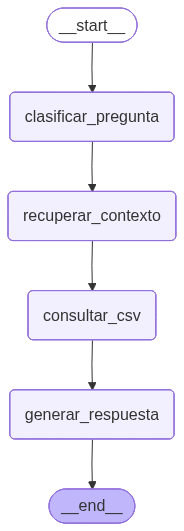

In [53]:
# Image y display permiten mostrar la imagen del grafo dentro del notebook.
from IPython.display import Image, display

# Dibujamos el grafo compilado en formato Mermaid PNG.
display(Image(agente_langgraph.get_graph().draw_mermaid_png()))

### 17.6 Funcion de uso del agente

Esta funcion recibe una pregunta, ejecuta el grafo y devuelve la respuesta. Tambien devuelve el estado completo para poder inspeccionar si se uso ChromaDB y pandas.

In [54]:
# Ejecuta el agente LangGraph con una pregunta del usuario.
def preguntar_agente(pregunta):
    # Estado inicial. Los campos se iran completando en los nodos.
    estado_inicial = {
        "pregunta": pregunta,
        "tipo_consulta": None,
        "contexto_rag": None,
        "fuentes_rag": None,
        "datos_csv": None,
        "respuesta": None,
    }

    # Ejecutamos el grafo.
    resultado = agente_langgraph.invoke(estado_inicial)

    # Devolvemos el estado final completo.
    return resultado

### 17.7 Pruebas del agente

Probamos tres tipos de preguntas: conceptual, ranking y comparacion. En todas ellas el agente recupera contexto desde ChromaDB.

In [44]:
# Prueba 1: pregunta conceptual, usa ChromaDB y Gemini.
resultado_agente_conceptual = preguntar_agente("Que significa xG y como se interpreta en scouting?")
print(resultado_agente_conceptual["respuesta"])

El xG, o Goles Esperados, es una métrica avanzada que representa la suma de las probabilidades de gol de los tiros realizados por un jugador o equipo. Su objetivo principal es evaluar la **calidad de las ocasiones generadas** (Fragmento 1 | fuente: 01_metricas_base_tiro_xg.pdf | pagina: 1).

En el scouting, el xG se interpreta de la siguiente manera:

*   **Evaluación de la calidad de las ocasiones:** Permite a los scouts entender si un jugador está llegando a posiciones de remate peligrosas, independientemente de si el tiro termina en gol o no. Un alto xG sugiere que el jugador se posiciona bien o genera tiros desde zonas de alta probabilidad.
*   **Análisis de sobre/subrendimiento:** Al comparar los Goles Anotados (Gls) de un jugador con su xG, se puede identificar si está rindiendo por encima (más goles que xG) o por debajo (menos goles que xG) de lo esperado. Esto puede indicar una gran capacidad de finalización o, por el contrario, una falta de puntería.
*   **Comparación ajustada

In [45]:
# Prueba 2: pregunta de ranking, usa ChromaDB + pandas + Gemini.
resultado_agente_ranking = preguntar_agente("Cuales son los jugadores con mas xG y que significa esta metrica?")
print(resultado_agente_ranking["respuesta"])

Los jugadores con mayor Goles Esperados (xG) son:

1.  **Robert Lewandowski** (Barcelona, La Liga): 27.1 xG
2.  **Kylian Mbappé** (Real Madrid, La Liga): 25.9 xG
3.  **Mohamed Salah** (Liverpool, Premier League): 25.2 xG
4.  **Serhou Guirassy** (Dortmund, Bundesliga): 22.7 xG
5.  **Erling Haaland** (Manchester City, Premier League): 22.0 xG
6.  **Hugo Ekitike** (Eint Frankfurt, Bundesliga): 21.6 xG
7.  **Harry Kane** (Bayern Munich, Bundesliga): 20.3 xG
8.  **Alexander Isak** (Newcastle Utd, Premier League): 20.3 xG
9.  **Moise Kean** (Fiorentina, Serie A): 19.4 xG
10. **Raphinha** (Barcelona, La Liga): 19.2 xG

### ¿Qué significa la métrica xG?

**xG (Goles Esperados)** es una métrica avanzada que representa la suma de las probabilidades de gol de los tiros realizados por un jugador. Su objetivo principal es evaluar la calidad de las ocasiones de gol que un jugador genera o de las que se beneficia (Fragmento recuperado 1 | fuente: 01_metricas_base_tiro_xg.pdf | pagina: 1).

En esencia

In [52]:
# Prueba 3: pregunta de comparacion, usa ChromaDB + pandas + Gemini.
resultado_agente_comparacion = preguntar_agente("Compara a Mohamed Salah y Erling Haaland usando xG, xAG, PrgC y SCA")
print(resultado_agente_comparacion["respuesta"])

Para comparar a Mohamed Salah y Erling Haaland, analizaremos las métricas de Goles Esperados (xG), Asistencias Esperadas (xAG), Conducciones Progresivas (PrgC) y Acciones que Crean Tiros (SCA), utilizando los datos proporcionados y el contexto de las definiciones.

Ambos jugadores son delanteros (FW) en la Premier League inglesa, pero sus minutos jugados son diferentes (Salah con 3371 minutos y Haaland con 2736 minutos), lo cual es importante considerar al comparar métricas totales.

Aquí están los datos clave para cada jugador:

| Métrica | Mohamed Salah (Liverpool) | Erling Haaland (Manchester City) |
| :------ | :------------------------ | :------------------------------- |
| xG      | 25.2                      | 22.0                             |
| xAG     | 14.2                      | 3.0                              |
| PrgC    | 154                       | 24                               |
| SCA     | 169                       | 71                               |
| SCA90   | 4.

### 17.8 Verificacion de uso de ChromaDB

Esta celda permite demostrar que el agente recupero fuentes desde la base vectorial.

In [48]:
# Mostramos las fuentes recuperadas por ChromaDB en la ultima pregunta.
resultado_agente_comparacion["fuentes_rag"]

[{'source': '01_metricas_base_tiro_xg.pdf',
  'doc_type': 'metric_pdf',
  'page': 2},
 {'doc_type': 'metric_pdf',
  'page': 2,
  'source': '01_metricas_base_tiro_xg.pdf'},
 {'source': '01_metricas_base_tiro_xg.pdf',
  'doc_type': 'metric_pdf',
  'page': 1},
 {'page': 1,
  'doc_type': 'metric_pdf',
  'source': '01_metricas_base_tiro_xg.pdf'}]

## 18. Memoria conversacional

El enunciado pide que el agente recuerde el contexto de preguntas anteriores. Para mantenerlo simple, usaremos una memoria en forma de lista de turnos (`historial_conversacion`) y se la pasaremos a Gemini cuando genere la respuesta.

Esta memoria no sustituye a ChromaDB: ChromaDB sigue aportando conocimiento externo; la memoria solo guarda el contexto reciente de la conversacion.

### 18.1 Estado del agente con memoria

Creamos una segunda version del estado que añade el campo `historial`. El resto del flujo es igual: clasificar, recuperar contexto, consultar CSV y generar respuesta.

In [55]:
# Estado del agente con memoria conversacional.
class AgentStateMemoria(TypedDict):
    # Pregunta actual del usuario.
    pregunta: str

    # Historial de conversacion en texto.
    historial: str

    # Tipo de consulta detectada.
    tipo_consulta: Optional[str]

    # Contexto recuperado desde ChromaDB.
    contexto_rag: Optional[str]

    # Metadatos de fuentes recuperadas.
    fuentes_rag: Optional[List[Dict[str, Any]]]

    # Datos calculados desde pandas.
    datos_csv: Optional[str]

    # Respuesta final.
    respuesta: Optional[str]

### 18.2 Nodo de generacion con memoria

Este nodo es igual al anterior, pero añade el historial al prompt para que Gemini pueda interpretar referencias como "esa metrica", "el anterior" o "los dos jugadores".

In [56]:
# Nodo de generacion que incluye historial conversacional.
def nodo_generar_respuesta_con_memoria(state: AgentStateMemoria):
    # Construimos el prompt con historial, pregunta actual, contexto RAG y datos CSV.
    prompt = f"""
{SYSTEM_PROMPT}

Historial reciente de la conversacion:
{state["historial"]}

Pregunta actual del usuario:
{state["pregunta"]}

Tipo de consulta detectada:
{state["tipo_consulta"]}

Contexto recuperado desde ChromaDB:
{state["contexto_rag"]}

Datos calculados desde el CSV con pandas:
{state["datos_csv"]}

Instrucciones:
- Usa el historial para entender referencias de seguimiento.
- Usa siempre el contexto recuperado desde ChromaDB para explicar metricas.
- Si hay datos del CSV, integrarlos en la respuesta.
- No inventes valores que no aparezcan en el contexto o en los datos del CSV.
- Si la pregunta depende del historial, explica brevemente a que elemento anterior te refieres.
""".strip()

    # Pedimos a Gemini la respuesta final.
    respuesta = llm.invoke(prompt)

    # Devolvemos la respuesta.
    return {"respuesta": respuesta.content}

### 18.3 Construccion del grafo con memoria

Reutilizamos los nodos anteriores para clasificar, recuperar contexto y consultar CSV. Solo cambiamos el nodo final para que tenga en cuenta el historial.

In [57]:
# Creamos un nuevo grafo con memoria.
graph_builder_memoria = StateGraph(AgentStateMemoria)

# Reutilizamos nodos ya creados.
graph_builder_memoria.add_node("clasificar_pregunta", nodo_clasificar_pregunta)
graph_builder_memoria.add_node("recuperar_contexto", nodo_recuperar_contexto)
graph_builder_memoria.add_node("consultar_csv", nodo_consultar_csv)

# Usamos el nodo nuevo que incluye memoria.
graph_builder_memoria.add_node("generar_respuesta", nodo_generar_respuesta_con_memoria)

# Definimos flujo desde START hasta END.
graph_builder_memoria.add_edge(START, "clasificar_pregunta")
graph_builder_memoria.add_edge("clasificar_pregunta", "recuperar_contexto")
graph_builder_memoria.add_edge("recuperar_contexto", "consultar_csv")
graph_builder_memoria.add_edge("consultar_csv", "generar_respuesta")
graph_builder_memoria.add_edge("generar_respuesta", END)

# Compilamos el grafo con memoria.
agente_langgraph_memoria = graph_builder_memoria.compile()

print("Agente LangGraph con memoria compilado correctamente")

Agente LangGraph con memoria compilado correctamente


### 18.4 Funcion de chat con memoria

Esta funcion guarda cada pregunta y respuesta en `historial_conversacion`. Para que el prompt no crezca demasiado, solo envia los ultimos turnos.

In [58]:
# Historial simple de conversacion.
historial_conversacion = []


# Convierte el historial en texto para incluirlo en el prompt.
def formatear_historial(historial, max_turnos=4):
    # Nos quedamos solo con los ultimos turnos para no hacer prompts enormes.
    turnos_recientes = historial[-max_turnos:]

    # Si no hay historial, devolvemos mensaje claro.
    if not turnos_recientes:
        return "No hay historial previo."

    # Convertimos cada turno a texto.
    lineas = []
    for i, turno in enumerate(turnos_recientes, start=1):
        lineas.append(f"Turno {i} - Usuario: {turno['pregunta']}")
        lineas.append(f"Turno {i} - Asistente: {turno['respuesta']}")

    return "".join(lineas)


# Ejecuta el agente con memoria y actualiza el historial.
def preguntar_agente_con_memoria(pregunta):
    # Formateamos historial antes de responder.
    historial_texto = formatear_historial(historial_conversacion)

    # Creamos estado inicial.
    estado_inicial = {
        "pregunta": pregunta,
        "historial": historial_texto,
        "tipo_consulta": None,
        "contexto_rag": None,
        "fuentes_rag": None,
        "datos_csv": None,
        "respuesta": None,
    }

    # Ejecutamos el grafo con memoria.
    resultado = agente_langgraph_memoria.invoke(estado_inicial)

    # Guardamos el turno en memoria.
    historial_conversacion.append({
        "pregunta": pregunta,
        "respuesta": resultado["respuesta"],
    })

    # Devolvemos estado final.
    return resultado

### 18.5 Ejemplo de memoria conversacional

Este ejemplo demuestra memoria con una pregunta de seguimiento. La segunda pregunta usa "esa metrica", que hace referencia a `PSxG+/-` mencionada en el turno anterior.

In [59]:
# Reiniciamos la memoria para que el ejemplo sea limpio.
historial_conversacion.clear()

# Primera pregunta: introduce la metrica PSxG+/-.
respuesta_memoria_1 = preguntar_agente_con_memoria("Explica que significa PSxG+/- para evaluar porteros")
print(respuesta_memoria_1["respuesta"])

El **PSxG+/-** (Post-Shot Expected Goals +/-) es una métrica avanzada fundamental para evaluar el rendimiento de los porteros, especialmente en su capacidad para detener tiros.

Aquí te explico su significado y utilidad:

1.  **PSxG (Post-Shot Expected Goals):** Antes de entender el PSxG+/-, es crucial comprender el PSxG. Esta métrica mide la **calidad de los tiros a puerta recibidos después de conocer la colocación del tiro**. A diferencia del xG tradicional, que se calcula antes de que el jugador dispare, el PSxG tiene en cuenta dónde fue dirigido el balón dentro de la portería, lo que permite **evaluar la dificultad real de las paradas** que un portero debería hacer. Un valor más alto de PSxG para un tiro indica que era un tiro más difícil de detener.

2.  **PSxG+/- (PSxG menos goles recibidos):** Esta métrica se calcula restando los goles que un portero ha recibido del total de PSxG que ha enfrentado.
    *   **Interpretación:** Representa las **paradas realizadas por encima o por 

In [60]:
# Segunda pregunta: depende del contexto anterior mediante "esa metrica".
respuesta_memoria_2 = preguntar_agente_con_memoria("Y si esa metrica es positiva, que interpretacion tendria?")
print(respuesta_memoria_2["respuesta"])

Retomando la explicación anterior sobre el **PSxG+/-**, si esta métrica es positiva, la interpretación es la siguiente:

Un valor **positivo en PSxG+/-** indica que el portero ha **encajado menos goles de los que se esperaría** dada la calidad y dificultad de los tiros a puerta que ha enfrentado.

En términos más sencillos:
*   Significa que el portero ha realizado **paradas "extra"** o ha evitado goles que, según el modelo de PSxG (que evalúa la dificultad real de los tiros post-disparo), un portero promedio en esas mismas situaciones probablemente habría encajado.
*   Es un fuerte indicador de un **rendimiento superior a la media en la detención de tiros**, mostrando una capacidad para "salvar" goles que eran difíciles de detener.

Como se mencionó anteriormente, es crucial recordar que esta métrica **requiere una muestra alta de tiros recibidos** para ser fiable. Un valor positivo en un portero con pocos minutos o pocos tiros enfrentados podría ser engañoso.


### 18.6 Verificacion del historial

Mostramos el historial guardado para evidenciar que el agente conserva los turnos de conversacion.

In [61]:
# Mostramos las preguntas guardadas en memoria.
for i, turno in enumerate(historial_conversacion, start=1):
    print(f"Turno {i}")
    print("Usuario:", turno["pregunta"])
    print("Asistente:", turno["respuesta"][:500], "...")
    print()

Turno 1
Usuario: Explica que significa PSxG+/- para evaluar porteros
Asistente: El **PSxG+/-** (Post-Shot Expected Goals +/-) es una métrica avanzada fundamental para evaluar el rendimiento de los porteros, especialmente en su capacidad para detener tiros.

Aquí te explico su significado y utilidad:

1.  **PSxG (Post-Shot Expected Goals):** Antes de entender el PSxG+/-, es crucial comprender el PSxG. Esta métrica mide la **calidad de los tiros a puerta recibidos después de conocer la colocación del tiro**. A diferencia del xG tradicional, que se calcula antes de que el juga ...

Turno 2
Usuario: Y si esa metrica es positiva, que interpretacion tendria?
Asistente: Retomando la explicación anterior sobre el **PSxG+/-**, si esta métrica es positiva, la interpretación es la siguiente:

Un valor **positivo en PSxG+/-** indica que el portero ha **encajado menos goles de los que se esperaría** dada la calidad y dificultad de los tiros a puerta que ha enfrentado.

En términos más sencillos:
* 

## Resultado de esta fase

En este punto ya tenemos:

- 3 PDFs de metricas cargados como documentos de conocimiento.
- PDFs divididos en chunks semanticos.
- Embeddings creados con Gemini.
- Base vectorial persistente en ChromaDB.
- Retriever probado antes de conectar el agente.
- RAG basico con Gemini usando contexto recuperado desde los PDFs.

A partir de aqui, el CSV completo se usara con pandas para consultar jugadores, rankings y filtros numericos exactos. Esta separacion hace el proyecto mas simple y fiable: ChromaDB explica metricas; pandas consulta datos de jugadores.